# 2 - AM Suppressed Carrier

## Überblick: Amplitudenmodulation (AM)

AM mit unterdrücktem Träger entsteht durch Unterdrückung des DC-Offsets im Basisbandsignal.

Unmodulierter Träger:

$$s_c(t) = U_c \cos(2\pi f_c t + \varphi_c)$$

Basisband (hier z. B. Cosinus):

$$u_m(t) = U_m \cos(2\pi f_m t + \varphi_m)$$

Normiertes Basisband:

$$\hat u_m(t) = \frac{u_m(t)}{\max |u_m(t)|}$$

AM-Signal mit Modulationsgrad $m$ und DC-Offset $DC$:

$$s_{AM}(t) = U_c \left(DC + m \hat u_m(t)\right)\cos(2\pi f_c t + \varphi_c)$$

Für ein Cosinus-Basisband gilt (aus der Hüllkurve):

$$m = \frac{U_{max} - U_{min}}{U_{max} + U_{min}}$$


## 0) Globale Konfiguration 

Hier werden alle gemeinsamen Simulationsparameter zentral gesetzt:

- Gesamtzeitdauer `T_obs`
- Abtastrate `fs`
- Signalpunkte `N_sig`
- FFT-Länge `N_fft`

So bleiben alle folgenden Zellen konsistent und gut vergleichbar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

# Globale Parameter
T_obs = 1            # Beobachtungsdauer [s]
fs = 200_000            # Abtastrate [Hz]
N_sig = int(T_obs * fs) # Anzahl Signalpunkte
N_fft = 16384           # FFT-Länge

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

# Träger-Schalter:
# - 'auto': mittlere Linie nur dann als Träger, wenn sie relativ stark genug ist
# - 'force': mittlere Linie immer als Träger behandeln
# - 'suppress': Träger bewusst ignorieren (DSB-SC)
carrier_mode = 'auto'
carrier_rel_threshold = 0.20  # in 'auto': U_mid >= threshold * max(U_seitenlinien)

t_plot_ms = 6.0         # konsistente Plotdauer für Zeitbereich [ms]

t = np.arange(N_sig) / fs
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

print(f'fs = {fs} Hz, T_obs = {T_obs} s, N_sig = {N_sig}, N_fft = {N_fft}, t_plot = {t_plot_ms} ms')

fs = 200000 Hz, T_obs = 1 s, N_sig = 200000, N_fft = 16384, t_plot = 6.0 ms


In [2]:
# 1) Unmodulierter Träger: Parameter + Signal
U_c = 1.0              # Trägeramplitude
f_c = 20_000.0         # Trägerfrequenz [Hz]
phi_c_deg = 0.0        # Trägerphase [deg]

phi_c = np.deg2rad(phi_c_deg)
s_c = U_c * np.cos(2*np.pi*f_c*t + phi_c)

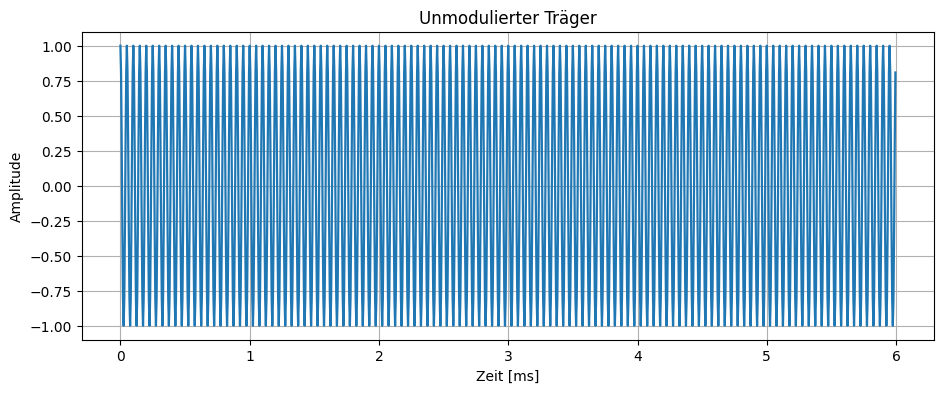

In [3]:
# Plot: unmodulierter Träger (Zeitbereich)
plt.figure()
plt.plot(t[:n_plot]*1e3, s_c[:n_plot], lw=1.6)
plt.title('Unmodulierter Träger')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

In [4]:
# 2) Basisbandsignal: Auswahl + Parameter
# wave_type in {'cosinus', 'dreieck', 'rechteck'}
wave_type = 'cosinus'

U_m = 1.0              # Basisbandamplitude
f_m = 200.0          # Basisbandfrequenz [Hz]
phi_m_deg = 0.0        # Basisbandphase [deg]

phi_m = np.deg2rad(phi_m_deg)
phase = 2*np.pi*f_m*t + phi_m

if wave_type == 'cosinus':
    u_m = U_m * np.cos(phase)
elif wave_type == 'dreieck':
    u_m = U_m * (2/np.pi) * np.arcsin(np.sin(phase))
elif wave_type == 'rechteck':
    u_m = U_m * np.sign(np.cos(phase))
else:
    raise ValueError("wave_type muss 'cosinus', 'dreieck' oder 'rechteck' sein.")

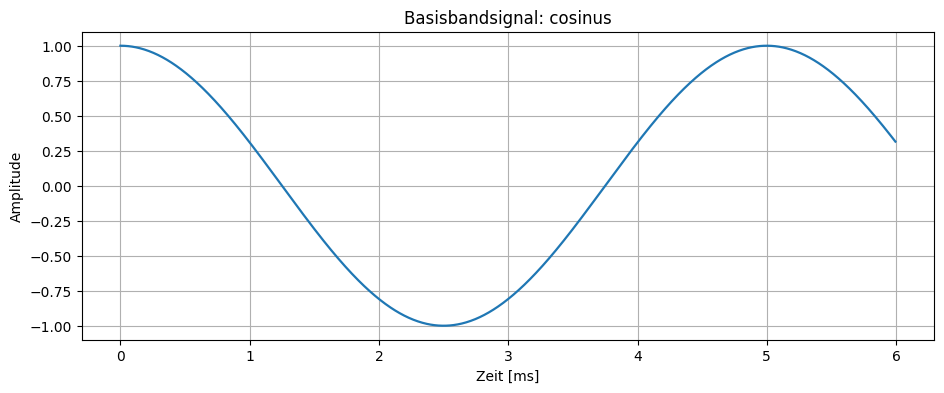

In [5]:
# Plot: Basisbandsignal (Zeitbereich)
plt.figure()
plt.plot(t[:n_plot]*1e3, u_m[:n_plot], lw=1.6)
plt.title(f'Basisbandsignal: {wave_type}')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

## Prinzip der AM

Didaktische Sicht:

1. Wir bilden aus dem Basisband ein normiertes Signal $\hat u_m(t)$.
2. Wir addieren einen DC-Offset: $DC + m \hat u_m(t)$.
3. Diese Hüllkurve multipliziert den Träger.

Formel des Amplitudenmodulators:

$$s_{AM}(t) = U_c\left(DC + m\hat u_m(t)\right)\cos(2\pi f_c t + \varphi_c)$$


In [6]:
# 3) AM-Modulator (Python-Implementierung)
m = 0.6   # Modulationsgrad für U_m = 1.0
DC = 1.0  # DC-Offset (für Trägerunterdrückung z. B. DC = 0)

# IMPLEMENTIERE den Amplitudenmodulator gemäß den bekannten Formeln
# Ersetze die Platzhalter

u_m_hat = u_m
envelope = np.zeros(N_sig)
s_am = np.zeros(N_sig)

envelope[:] = 1 + m * u_m_hat[:]
s_am[:] = U_c * envelope[:] * np.cos(2 * np.pi * f_c * t[:] + phi_m_deg)

print(f'm = {m:.3f}, DC = {DC:.3f}, min(envelope) = {envelope.min():.3f}, max(envelope) = {envelope.max():.3f}')

m = 0.600, DC = 1.000, min(envelope) = 0.400, max(envelope) = 1.600


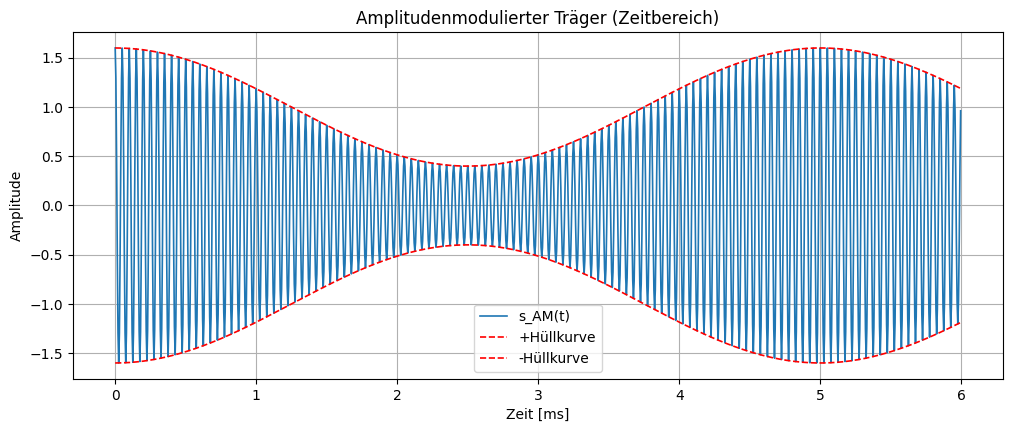

In [7]:
# Plot: AM-Signal im Zeitbereich (mit Hüllkurve)
plt.figure(figsize=(12, 4.5))
plt.plot(t[:n_plot]*1e3, s_am[:n_plot], label='s_AM(t)', lw=1.2)
plt.plot(t[:n_plot]*1e3, (U_c*envelope)[:n_plot], 'r--', lw=1.2, label='+Hüllkurve')
plt.plot(t[:n_plot]*1e3, (-U_c*envelope)[:n_plot], 'r--', lw=1.2, label='-Hüllkurve')
plt.title('Amplitudenmodulierter Träger (Zeitbereich)')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [8]:
# 4a) Peak-Suche als eigene Funktion (Sliding-Window-Maximum, ohne SciPy)
def find_peaks_sliding_window(
    a: np.ndarray,
    k: int = 21,
    min_height: float = 0.0,
    return_window_max: bool = False,
):
    """
    Lokale Maxima per Sliding-Window-Maximum.

    Idee:
    1) Für jedes Sample wird das Maximum in einem Fenster der Breite k bestimmt.
    2) Dort, wo ungefiltertes Signal und Fenster-Maximum gleich sind, liegen Peak-Kandidaten.
    3) Zusammenhängende Kandidaten-Plateaus werden auf genau einen Peak reduziert
       (Index des stärksten Samples im Plateau).

    Parameter:
    - a: 1D-Signal
    - k: Fensterbreite (ungerade empfohlen, > 1)
    - min_height: optionale Mindesthöhe
    """
    x = np.asarray(a, dtype=float).ravel()
    n = x.size
    if n == 0:
        if return_window_max:
            return np.array([], dtype=int), np.array([], dtype=float)
        return np.array([], dtype=int)

    k = max(3, int(k))
    if k % 2 == 0:
        k += 1
    h = k // 2

    # Sliding-Window-Maximum (didaktisch klar, nicht auf Laufzeit optimiert)
    max_filt = np.empty(n, dtype=float)
    for i in range(n):
        i0 = max(0, i - h)
        i1 = min(n, i + h + 1)
        max_filt[i] = np.max(x[i0:i1])

    # Peak-Kandidaten: Original trifft Fenster-Maximum + Mindesthoehe
    cand = np.isclose(x, max_filt, rtol=0.0, atol=1e-14) & (x >= float(min_height))
    idx = np.flatnonzero(cand)
    if idx.size == 0:
        if return_window_max:
            return np.array([], dtype=int), max_filt
        return np.array([], dtype=int)

    # Kandidaten-Plateaus zu je einem Peak zusammenfassen
    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    peaks = []
    for g in groups:
        j = g[np.argmax(x[g])]
        peaks.append(int(j))

    peaks = np.array(peaks, dtype=int)
    if return_window_max:
        return peaks, max_filt
    return peaks


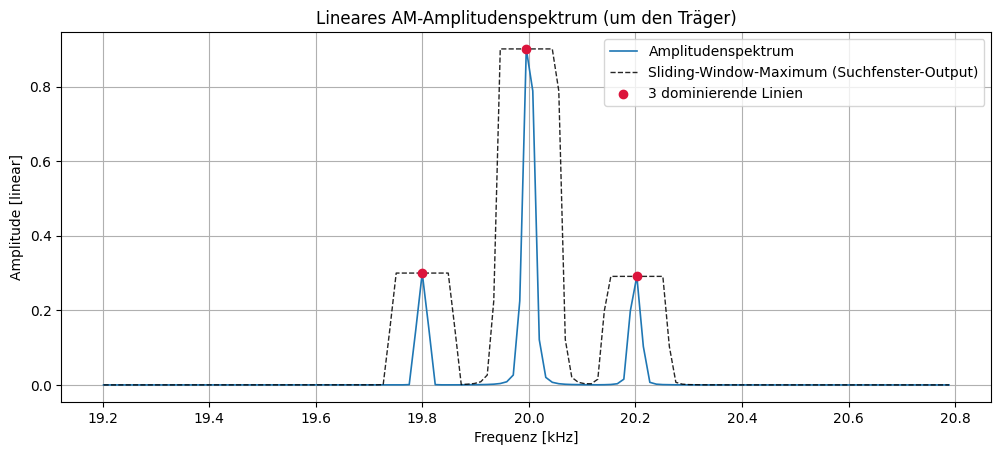

Spektrale Auflösung: df = 12.207 Hz
Peak-Suche (Sliding-Window): window = 8 Bins (~97.7 Hz), min_height >= 1.8020e-02, min_distance = 10 Bins (~120.0 Hz)
Akzeptierte lokale Maxima nach Distanzfilter: 3
Die gestrichelte Kurve zeigt den Output des Suchfensters (Sliding-Window-Maximum).
Trägermodus: auto, erkannt: True

--- Modulationsgrad aus Spektrum ---
m_est,lo = 0.6658, m_est,hi = 0.6461, m_est = 0.6559

--- Erkannte Spektrallinien (Tabelle) ---


,Linie,Frequenz [Hz],Delta zu Träger [Hz],Amplitude [linear],m aus Linie
0,Seitenlinie unten,19799.804687,-195.312500,0.299927,0.665771
1,Träger,19995.117187,0.000000,0.900992,NaN
2,Seitenlinie oben,20202.636719,207.519531,0.291058,0.646085


In [9]:
# 4) Spektrum berechnen und plotten (lineares Amplitudenspektrum)
import pandas as pd
from IPython.display import display

x = np.zeros(N_fft)
n_copy = min(N_sig, N_fft)
x[:n_copy] = s_am[:n_copy]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

X = np.fft.fft(x * w, n=N_fft)
f = np.fft.fftfreq(N_fft, d=1/fs)

# Einseitiges lineares Amplitudenspektrum (kohärente Verstärkung kompensieren)
cg = np.mean(w)
mask = f >= 0
f_pos = f[mask]
A_pos = (2.0 / (N_fft * max(cg, 1e-12))) * np.abs(X[mask])

df = fs / N_fft

# Suchfenster um den erwarteten Träger
band = (f_pos >= max(0.0, f_c - 4*f_m)) & (f_pos <= (f_c + 4*f_m))
f_band = f_pos[band]
A_band = A_pos[band]

# WICHTIG (didaktisch): lokale Maxima per Sliding-Window-Maximum.
# Eine Spektrallinie ist oft breiter als 1 FFT-Bin; daher erst Peak-Kandidaten als
# "Original == Fenstermaximum" bestimmen und dann die stärksten auswählen.

# Parametrierung der transparenten Peak-Suche
peak_window_hz = max(0.25 * f_m, 8 * df)                   # Fensterbreite [Hz]
peak_window_bins = max(3, int(np.round(peak_window_hz / df)))
peak_min_height = 0.02 * np.max(A_band)
peak_min_distance_hz = max(0.6 * f_m, peak_window_hz)      # Mindestabstand zwischen Peaks [Hz]
peak_min_distance_bins = max(1, int(np.round(peak_min_distance_hz / df)))

peaks, A_winmax = find_peaks_sliding_window(
    A_band,
    k=peak_window_bins,
    min_height=peak_min_height/2,
    return_window_max=True,
)

# Peaks nach Amplitude sortieren und mit Mindestabstand ausdünnen,
# damit keine zwei Maxima aus derselben Spektrallinie gewählt werden.
peak_candidates = peaks[np.argsort(A_band[peaks])[::-1]] if peaks.size else np.array([], dtype=int)
selected = []
for p in peak_candidates:
    if all(abs(int(p) - int(q)) >= peak_min_distance_bins for q in selected):
        selected.append(int(p))
    if len(selected) >= 3:
        break

idx_sel = np.array(selected, dtype=int)
if idx_sel.size < 2:
    raise ValueError(
        'Zu wenige lokale Maxima über Threshold gefunden. '
        'Bitte min_height reduzieren oder Beobachtungs-/FFT-Parameter anpassen.'
    )

idx_sorted_freq = idx_sel[np.argsort(f_band[idx_sel])]
freqs = f_band[idx_sorted_freq]
amps = A_band[idx_sorted_freq]

# Trägerentscheidung:
# - bei 3 Peaks: mittlere Linie kann Träger sein
# - bei 2 Peaks: nur Seitenlinien detektiert
force_carrier_unavailable = False
if freqs.size >= 3:
    freqs3 = freqs[-3:]
    amps3 = amps[-3:]
    U_mid = amps3[1]
    U_sb_ref = max(amps3[0], amps3[2])

    carrier_detected = True
    if carrier_mode == 'suppress':
        carrier_detected = False
    elif carrier_mode == 'auto':
        carrier_detected = U_mid >= carrier_rel_threshold * max(U_sb_ref, 1e-12)

    if carrier_detected:
        f_c_est = freqs3[1]
        U_c_est = amps3[1]
        f_sb_lo, f_sb_hi = freqs3[0], freqs3[2]
        U_sb_lo, U_sb_hi = amps3[0], amps3[2]
    else:
        f_c_est = np.nan
        U_c_est = np.nan
        f_sb_lo, f_sb_hi = freqs3[0], freqs3[2]
        U_sb_lo, U_sb_hi = amps3[0], amps3[2]

    freqs = freqs3
    amps = amps3
else:
    carrier_detected = False
    if carrier_mode == 'force':
        force_carrier_unavailable = True

    f_c_est = np.nan
    U_c_est = np.nan
    f_sb_lo, f_sb_hi = freqs[0], freqs[1]
    U_sb_lo, U_sb_hi = amps[0], amps[1]

Delta_f_lo = (f_c_est - f_sb_lo) if carrier_detected else np.nan
Delta_f_hi = (f_sb_hi - f_c_est) if carrier_detected else np.nan

# Modulationsgrad aus Spektrum:
# - mit sichtbarem Träger: U_SB = (m/2) * U_C -> m = 2*U_SB/U_C
# - bei unterdrücktem Träger: U_c aus Parametern verwenden (hier bekannt aus Synthese)
if carrier_detected:
    m_est_lo = 2 * U_sb_lo / max(U_c_est, 1e-12)
    m_est_hi = 2 * U_sb_hi / max(U_c_est, 1e-12)
else:
    m_est_lo = 2 * U_sb_lo / max(U_c, 1e-12)
    m_est_hi = 2 * U_sb_hi / max(U_c, 1e-12)

m_est = 0.5 * (m_est_lo + m_est_hi)

plt.figure(figsize=(12, 4.8))
plt.plot(f_band/1e3, A_band, lw=1.2, label='Amplitudenspektrum')
plt.plot(
    f_band/1e3,
    A_winmax,
    'k--',
    lw=1.0,
    alpha=0.85,
    label='Sliding-Window-Maximum (Suchfenster-Output)',
)
if carrier_detected:
    plt.scatter(freqs/1e3, amps, color='crimson', zorder=4, label='3 dominierende Linien')
else:
    plt.scatter([f_sb_lo/1e3, f_sb_hi/1e3], [U_sb_lo, U_sb_hi], color='crimson', zorder=4,
                label='2 Seitenlinien (Träger unterdrückt)')
plt.title('Lineares AM-Amplitudenspektrum (um den Träger)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [linear]')
plt.legend()
plt.show()

print(f'Spektrale Auflösung: df = {df:.3f} Hz')
print(
    f"Peak-Suche (Sliding-Window): window = {peak_window_bins} Bins (~{peak_window_hz:.1f} Hz), "
    f"min_height >= {peak_min_height:.4e}, min_distance = {peak_min_distance_bins} Bins (~{peak_min_distance_hz:.1f} Hz)"
)
print(f"Akzeptierte lokale Maxima nach Distanzfilter: {idx_sel.size}")
print('Die gestrichelte Kurve zeigt den Output des Suchfensters (Sliding-Window-Maximum).')
print(f"Trägermodus: {carrier_mode}, erkannt: {carrier_detected}")
if force_carrier_unavailable:
    print('Hinweis: carrier_mode="force" angefordert, aber es wurden nur 2 valide Peaks gefunden.')
if not carrier_detected:
    print("Hinweis: Trägerlinie unter Schwellwert bzw. absichtlich unterdrückt -> mittlere Linie ignoriert.")
print('\n--- Modulationsgrad aus Spektrum ---')
print(f'm_est,lo = {m_est_lo:.4f}, m_est,hi = {m_est_hi:.4f}, m_est = {m_est:.4f}')

# Tabelle der dominanten Spektrallinien
if carrier_detected:
    df_lines = pd.DataFrame([
        {
            'Linie': 'Seitenlinie unten',
            'Frequenz [Hz]': float(f_sb_lo),
            'Delta zu Träger [Hz]': float(-Delta_f_lo),
            'Amplitude [linear]': float(U_sb_lo),
            'm aus Linie': float(m_est_lo),
        },
        {
            'Linie': 'Träger',
            'Frequenz [Hz]': float(f_c_est),
            'Delta zu Träger [Hz]': 0.0,
            'Amplitude [linear]': float(U_c_est),
            'm aus Linie': np.nan,
        },
        {
            'Linie': 'Seitenlinie oben',
            'Frequenz [Hz]': float(f_sb_hi),
            'Delta zu Träger [Hz]': float(Delta_f_hi),
            'Amplitude [linear]': float(U_sb_hi),
            'm aus Linie': float(m_est_hi),
        },
    ])
else:
    df_lines = pd.DataFrame([
        {
            'Linie': 'Seitenlinie unten',
            'Frequenz [Hz]': float(f_sb_lo),
            'Delta zu Träger [Hz]': np.nan,
            'Amplitude [linear]': float(U_sb_lo),
            'm aus Linie': float(m_est_lo),
        },
        {
            'Linie': 'Seitenlinie oben',
            'Frequenz [Hz]': float(f_sb_hi),
            'Delta zu Träger [Hz]': np.nan,
            'Amplitude [linear]': float(U_sb_hi),
            'm aus Linie': float(m_est_hi),
        },
    ])

print('\n--- Erkannte Spektrallinien (Tabelle) ---')
display(df_lines)


## Save Modulated Carrier

Ziel: Das modulierte Trägersignal für ein Folge-Notebook (Demodulation) speichern.

Empfehlung: binäres NumPy-Format (`.npy`) — schnell, präzise und einfach wieder einzulesen.

In [10]:
from pathlib import Path

# Zielpfad relativ zum aktuellen Notebook-Ordner
out_name = 'AM-carrier.npy'
out_path = Path.cwd() / out_name

# Optionales Metadatenobjekt für späteres Demodulations-Notebook
meta = {
    'fs_hz': float(fs),
    'f_c_hz': float(f_c),
    'f_m_hz': float(f_m),
    'm': float(m),
    'DC': float(DC),
    'U_c': float(U_c),
    'wave_type': str(wave_type),
    'N_sig': int(N_sig),
}

np.save(out_path, s_am.astype(np.float64))
np.save(out_path.with_name('AM-carrier-meta.npy'), meta, allow_pickle=True)

print(f'Gespeichert: {out_path}')
print(f'Gespeichert: {out_path.with_name("AM-carrier-meta.npy")}')
print('Laden im Folge-Notebook: s = np.load("AM-carrier.npy")')

Gespeichert: /home/student/Documents/KT-course/lab_suite/labs/04_01_LABOR-4/submissions/AM-carrier.npy
Gespeichert: /home/student/Documents/KT-course/lab_suite/labs/04_01_LABOR-4/submissions/AM-carrier-meta.npy
Laden im Folge-Notebook: s = np.load("AM-carrier.npy")
